# Classification -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 06

Companion notebook to the Classification slides. Same approach as every notebook so far: every
claim gets a real, runnable demonstration -- not just a formula. K-Nearest Neighbors is today's
running example, used purely to build intuition before Decision Trees, Logistic Regression, and
SVM each bring their own strategy in the next three lectures.

**session structure:**
1. A simple first classifier -- K-Nearest Neighbors, and what "training" even means for it
2. Decision boundaries -- the visual version of overfitting, for classifiers
3. Probabilities first, labels second -- `predict_proba` vs. `predict`
4. The confusion matrix -- the foundation of every metric that follows
5. Accuracy, and why it lies on imbalanced data
6. Precision and recall -- two different kinds of "wrong," and their tradeoff
7. F1 score -- one balanced number
8. Choosing a threshold based on real costs
9. ROC curve and AUC -- the big-picture view
10. Class imbalance -- reweighting and resampling
11. Multiclass classification
12. Comparing classifiers honestly, with cross-validation

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.datasets import make_classification, make_blobs
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report, roc_curve, roc_auc_score,
                              RocCurveDisplay, precision_recall_curve)

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.5.3 | Pandas: 3.0.5


---
## Part 1 -- A Simple First Classifier: K-Nearest Neighbors

**The mental model, in one sentence:** to classify a new point, find the `k` closest points in the
training data and let them vote. Whatever category is most common among those neighbors is the
prediction.

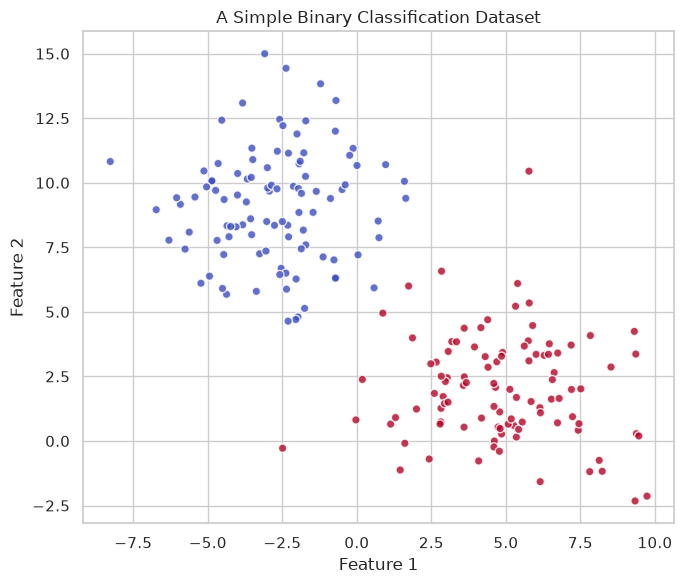

In [6]:
# A simple 2D dataset, on purpose -- two features only, so decision boundaries can be drawn and
# seen directly, exactly the way the slides describe them.
X_blob, y_blob = make_blobs(n_samples=200, centers=2, cluster_std=2.2, random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('A Simple Binary Classification Dataset')
plt.tight_layout()
plt.show()

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_blob, y_blob)

# A brand-new point, not in the training data at all -- watch how KNN classifies it.
new_point = np.array([[0, 0]])
prediction = knn.predict(new_point)
neighbor_distances, neighbor_indices = knn.kneighbors(new_point)

print(f'New point at {new_point[0]} is predicted as class {prediction[0]}')
print(f"Its {knn.n_neighbors} nearest neighbors' classes: {y_blob[neighbor_indices[0]]}")
print('The predicted class is simply whichever class is most common among those neighbors.')

New point at [0 0] is predicted as class 1
Its 5 nearest neighbors' classes: [1 1 1 1 1]
The predicted class is simply whichever class is most common among those neighbors.


**Notice there was no real "training" happening in `.fit()` above** -- KNN just stored the data.
All the actual work happens at prediction time: measure distance to every training point, find the
`k` closest, count votes. This is different from every model we'll meet later, which all learn
some compact set of parameters during `.fit()` instead.

---
## Part 2 -- Decision Boundaries: Seeing How a Classifier Thinks

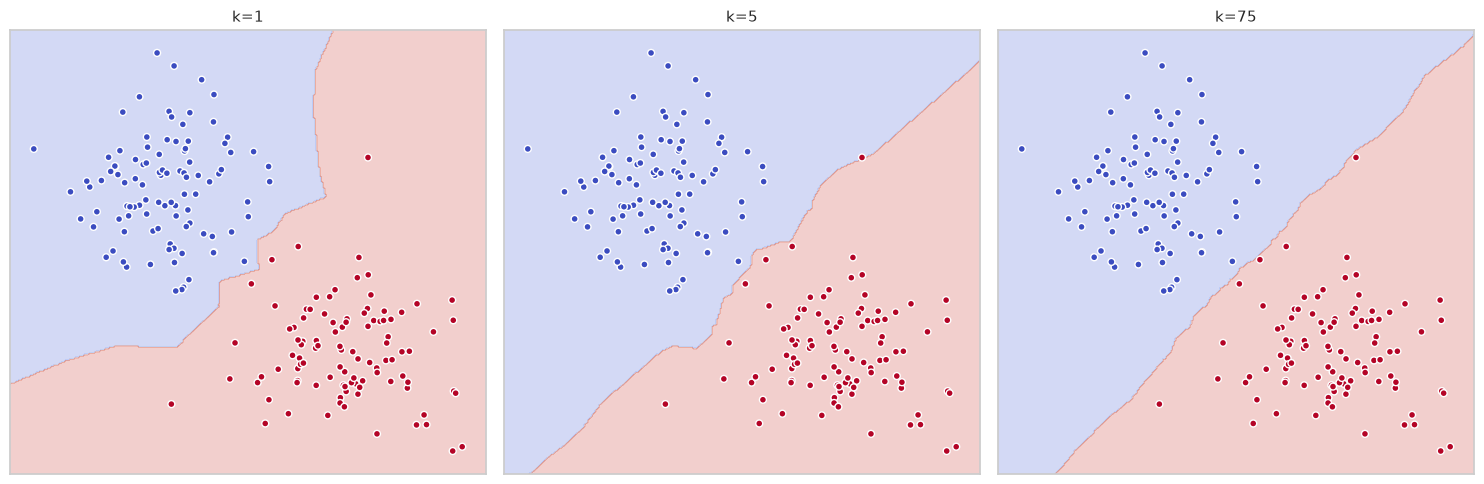

In [8]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='white', s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, [1, 5, 75]):
    model = KNeighborsClassifier(n_neighbors=k).fit(X_blob, y_blob)
    plot_decision_boundary(model, X_blob, y_blob, ax, f'k={k}')

plt.tight_layout()
plt.show()

**Read these three panels exactly like Lecture 01's underfit/good-fit/overfit curves:**

- **k=1 (left):** the boundary wraps tightly around individual points -- a single noisy point can
  carve out its own little island. This is **overfitting**: perfect memorization of training data,
  unlikely to generalize well.
- **k=5 (middle):** a smooth, reasonable boundary that separates the two groups without chasing
  every individual point. This is the **good fit**.
- **k=75 (right):** with so many neighbors voting, the boundary becomes almost a straight line,
  ignoring local structure entirely. This is **underfitting** -- too simple to capture real
  structure in the data.

**The concrete lesson: `k` is a hyperparameter, tuned exactly like any other** (Lecture 04) --
small `k` risks overfitting, large `k` risks underfitting, and cross-validation is how you'd
actually pick a good value rather than guessing.

---
## Part 3 -- Probabilities First, Labels Second

A synthetic churn-style dataset -- the same shape of problem as the capstone, but self-contained
here so this notebook runs on its own.

In [9]:
rng = np.random.default_rng(42)
n = 800
tenure_months = rng.integers(1, 72, n)
monthly_charges = rng.normal(70, 25, n).clip(20, 150)
contract_month_to_month = rng.choice([0, 1], n, p=[0.45, 0.55])

churn_score = (-0.04 * tenure_months + 0.02 * monthly_charges + 1.3 * contract_month_to_month - 2.3
               + rng.normal(0, 1, n))
churn_prob_true = 1 / (1 + np.exp(-churn_score))
churn = rng.binomial(1, churn_prob_true)

churn_df = pd.DataFrame({'tenure_months': tenure_months, 'monthly_charges': monthly_charges,
                          'contract_month_to_month': contract_month_to_month, 'churn': churn})
print(f'Churn rate: {churn_df["churn"].mean():.1%}')
churn_df.head()

Churn rate: 26.1%


,tenure_months,monthly_charges,contract_month_to_month,churn
0,7,80.990915,1,0
1,55,83.104696,1,1
2,47,76.906854,0,0
3,32,34.680853,1,0
4,31,20.000000,1,0


In [10]:
X = churn_df[['tenure_months', 'monthly_charges', 'contract_month_to_month']]
y = churn_df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

probabilities = clf.predict_proba(X_test_scaled)
hard_labels = clf.predict(X_test_scaled)

comparison = pd.DataFrame({
    'prob_stay': probabilities[:5, 0], 'prob_churn': probabilities[:5, 1], 'hard_label': hard_labels[:5]
})
print(comparison.round(3))

   prob_stay  prob_churn  hard_label
0      0.853       0.147           0
1      0.887       0.113           0
2      0.893       0.107           0
3      0.442       0.558           1
4      0.932       0.068           0


**`.predict_proba()` returns two columns -- probability of each class -- and `.predict()` is
nothing more than "pick whichever probability is higher."** Two customers at 51% and 98% churn
probability both get the same hard label, "churn" -- but they are very different cases in practice.
Anywhere prioritization matters (who does a retention team call first?), the probability column is
the useful one, not the label.

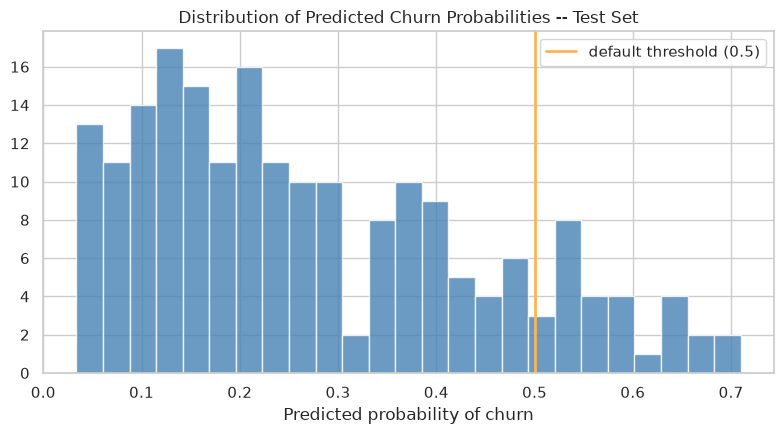

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(probabilities[:, 1], bins=25, color='steelblue', alpha=0.8)
ax.axvline(0.5, color='#ffb454', linewidth=2, label='default threshold (0.5)')
ax.set_xlabel('Predicted probability of churn')
ax.set_title('Distribution of Predicted Churn Probabilities -- Test Set')
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 4 -- The Confusion Matrix

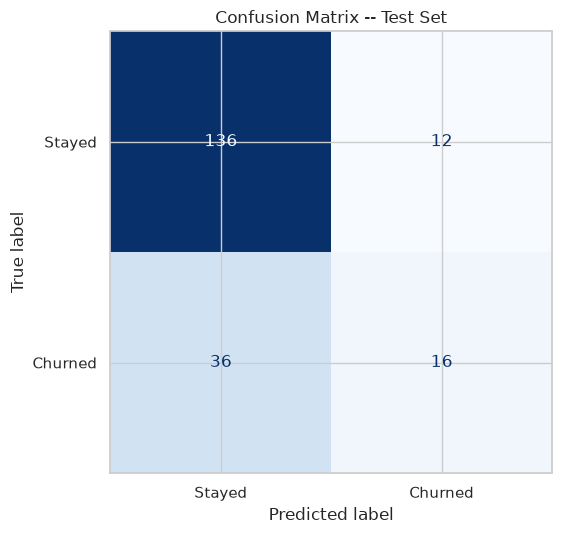

True Positives  (correctly caught churners):    16
False Negatives (missed churners):               36
False Positives (false alarms):                  12
True Negatives  (correctly ignored non-churners): 136


In [12]:
cm = confusion_matrix(y_test, hard_labels)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5.5))
ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix -- Test Set')
plt.tight_layout()
plt.show()

print(f'True Positives  (correctly caught churners):    {tp}')
print(f'False Negatives (missed churners):               {fn}')
print(f'False Positives (false alarms):                  {fp}')
print(f'True Negatives  (correctly ignored non-churners): {tn}')

**Every metric in the rest of this notebook is just a different arithmetic combination of these
four numbers.** Worth pausing here until these four are completely comfortable before moving on --
everything downstream depends on reading this table correctly.

---
## Part 5 -- Accuracy, and Why It Lies on Imbalanced Data

In [13]:
print(f'Accuracy on the churn test set: {accuracy_score(y_test, hard_labels):.3f}')

Accuracy on the churn test set: 0.760


**That number alone looks fine -- but let's build the classic trap directly, with a much more
imbalanced dataset, to see exactly how accuracy can mislead.**

In [14]:
# A severely imbalanced dataset -- 95% one class, 5% the other, similar to real fraud/disease rates.
X_imb, y_imb = make_classification(n_samples=2000, weights=[0.95, 0.05], n_features=6, random_state=1)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=1)

print(f'Class balance in test set: {np.bincount(y_test_imb)} (majority, minority)')

# A "model" that does the least possible amount of thinking: always predict the majority class.
lazy_predictions = np.zeros_like(y_test_imb)
print(f"\n'Always predict majority class' accuracy: {accuracy_score(y_test_imb, lazy_predictions):.3f}")
print(f"'Always predict majority class' recall on the minority class: "
      f"{recall_score(y_test_imb, lazy_predictions, pos_label=1):.3f}")

Class balance in test set: [568  32] (majority, minority)

'Always predict majority class' accuracy: 0.947
'Always predict majority class' recall on the minority class: 0.000


**A model that does zero real work -- never even looks at the features -- scores extremely high
accuracy, and catches exactly none of the minority class.** This is not a hypothetical: it's the
single most common way a classification project accidentally reports an impressive-looking number
that is actually useless. Accuracy alone can never catch this; precision, recall, and F1 (next)
can.

---
## Part 6 -- Precision and Recall

In [15]:
precision = precision_score(y_test, hard_labels)
recall = recall_score(y_test, hard_labels)

print(f'Precision: {precision:.3f}  -- of everyone we FLAGGED as churn, this fraction really churned')
print(f'Recall:    {recall:.3f}  -- of everyone who REALLY churned, this fraction we successfully caught')
print()
print(f'By hand, from the confusion matrix:')
print(f'  Precision = TP / (TP + FP) = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.3f}')
print(f'  Recall    = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.3f}')

Precision: 0.571  -- of everyone we FLAGGED as churn, this fraction really churned
Recall:    0.308  -- of everyone who REALLY churned, this fraction we successfully caught

By hand, from the confusion matrix:
  Precision = TP / (TP + FP) = 16 / (16 + 12) = 0.571
  Recall    = TP / (TP + FN) = 16 / (16 + 36) = 0.308


**Tie each one to a real cost, out loud, before trusting either number:**
- **Low precision** means a lot of false alarms -- retention offers sent to customers who were
  never going to leave. Wasted effort, mildly annoying, rarely disastrous.
- **Low recall** means a lot of missed churners -- customers who leave silently, with nobody ever
  reaching out. Directly lost revenue, no second chance.

For this specific business problem, missing a churner is probably worse than one unnecessary
email -- which is exactly the kind of judgment call that should drive threshold choice (Part 8),
not a formula.

---
## Part 7 -- The Precision-Recall Tradeoff, Made Concrete

In [16]:
probabilities_churn = clf.predict_proba(X_test_scaled)[:, 1]
thresholds_to_try = [0.1, 0.2, 0.3, 0.4, 0.6]

results = []
for t in thresholds_to_try:
    preds_at_t = (probabilities_churn >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, preds_at_t, zero_division=0),
        'recall': recall_score(y_test, preds_at_t, zero_division=0),
        'n_flagged_as_churn': preds_at_t.sum(),
    })

results_df = pd.DataFrame(results)
print(results_df)

   threshold  precision    recall  n_flagged_as_churn
0        0.1   0.303571  0.980769                 168
1        0.2   0.380531  0.826923                 113
2        0.3   0.452055  0.634615                  73
3        0.4   0.555556  0.480769                  45
4        0.6   0.600000  0.115385                  10


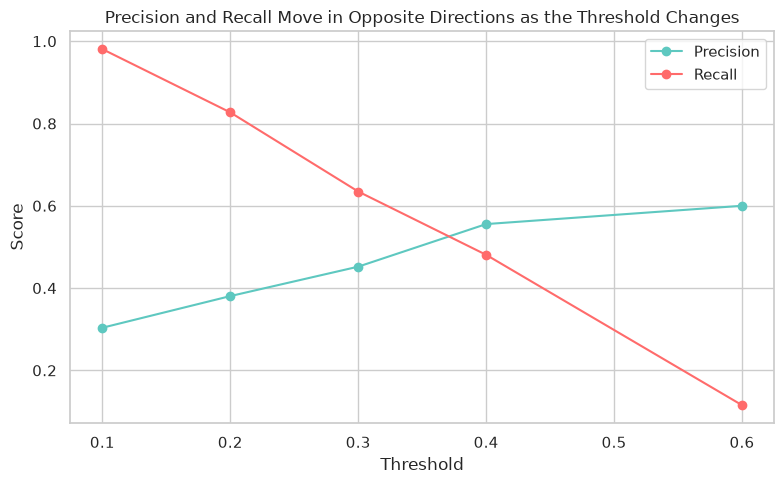

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df['threshold'], results_df['precision'], marker='o', color='#5ec8c0', label='Precision')
ax.plot(results_df['threshold'], results_df['recall'], marker='o', color='#ff6b6b', label='Recall')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision and Recall Move in Opposite Directions as the Threshold Changes')
ax.legend()
plt.tight_layout()
plt.show()

**Read the table before the chart:** as the threshold rises from 0.1 to 0.9, the model gets pickier
about who it flags -- fewer people flagged, but a higher fraction of them really are churners
(precision rises). At the same time, it inevitably misses more real churners who didn't clear the
higher bar (recall falls). This is the tradeoff from the slides, with real numbers instead of an
abstract description.

---
## Part 8 -- F1 Score: One Balanced Number

In [18]:
for t in thresholds_to_try:
    preds_at_t = (probabilities_churn >= t).astype(int)
    p = precision_score(y_test, preds_at_t, zero_division=0)
    r = recall_score(y_test, preds_at_t, zero_division=0)
    f1 = f1_score(y_test, preds_at_t, zero_division=0)
    naive_avg = (p + r) / 2
    print(f'threshold={t:.1f}  precision={p:.3f}  recall={r:.3f}  F1={f1:.3f}  (naive average={naive_avg:.3f})')

threshold=0.1  precision=0.304  recall=0.981  F1=0.464  (naive average=0.642)
threshold=0.2  precision=0.381  recall=0.827  F1=0.521  (naive average=0.604)
threshold=0.3  precision=0.452  recall=0.635  F1=0.528  (naive average=0.543)
threshold=0.4  precision=0.556  recall=0.481  F1=0.515  (naive average=0.518)
threshold=0.6  precision=0.600  recall=0.115  F1=0.194  (naive average=0.358)


**Compare the F1 column to the naive-average column, especially at the extreme thresholds.** When
precision and recall are close together, F1 and the naive average agree closely. When they're far
apart (very high threshold: high precision, low recall), F1 drops noticeably below the naive
average -- it's specifically designed to punish that kind of lopsided result rather than papering
over it. That's the "harmonic mean" behavior from the slides, visible directly in the numbers.

---
## Part 9 -- Choosing a Threshold Based on Real Costs

In [19]:
# Assign concrete dollar costs to each type of mistake -- exactly the slide's example.
cost_per_false_negative = 100   # a missed churner: lost revenue
cost_per_false_positive = 30    # an unnecessary retention call: a real but smaller cost

threshold_range = np.arange(0.05, 0.96, 0.05)
total_costs = []
for t in threshold_range:
    preds_at_t = (probabilities_churn >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_at_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    total_cost = fn_t * cost_per_false_negative + fp_t * cost_per_false_positive
    total_costs.append(total_cost)

best_threshold = threshold_range[np.argmin(total_costs)]
print(f'Threshold that minimizes total cost: {best_threshold:.2f}')
print(f'(For comparison, the default threshold is 0.50)')

Threshold that minimizes total cost: 0.25
(For comparison, the default threshold is 0.50)


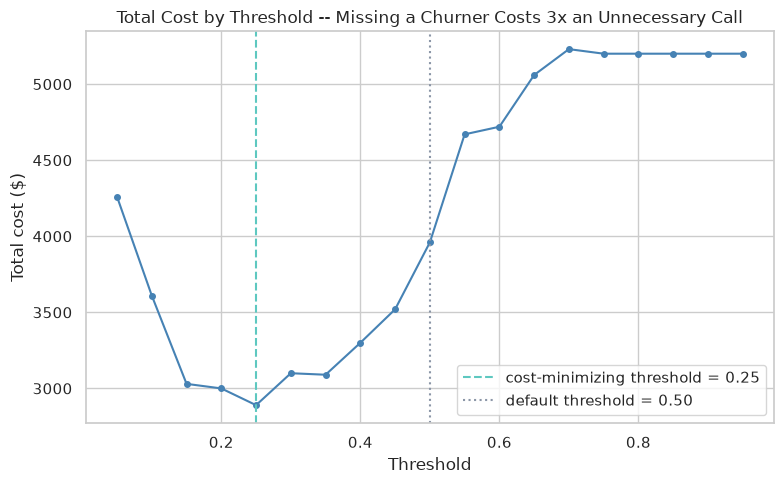

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_range, total_costs, color='steelblue', marker='o', markersize=4)
ax.axvline(best_threshold, color='#5ec8c0', linestyle='--', label=f'cost-minimizing threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='#8b96a7', linestyle=':', label='default threshold = 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('Total cost ($)')
ax.set_title('Total Cost by Threshold -- Missing a Churner Costs 3x an Unnecessary Call')
ax.legend()
plt.tight_layout()
plt.show()

**Because a missed churner ($100) costs more than an unnecessary retention call ($30), the
cost-minimizing threshold sits below the default 0.5** -- the model should flag more people as
"at risk" than it would by default, tolerating some extra false alarms to avoid the costlier false
negatives. This is the slides' business-driven threshold decision, computed directly rather than
asserted -- and notice the cost curve genuinely dips and rises around this point, rather than
just decreasing all the way to the edge of the range tried: there really is a best middle ground,
not just "always flag everyone."

---
## Part 10 -- ROC Curve and AUC

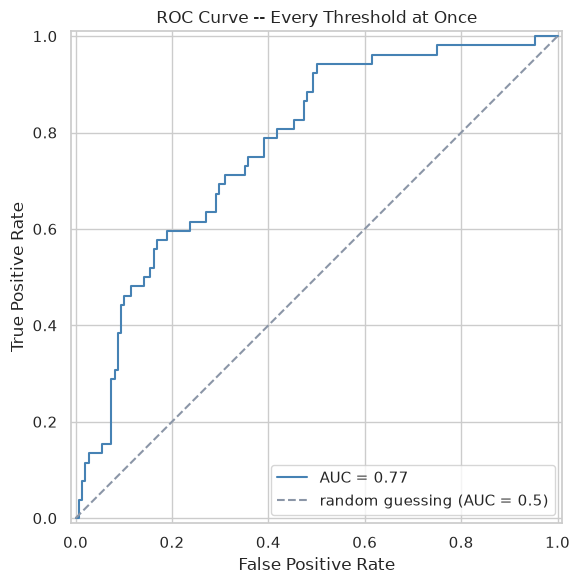

In [21]:
fpr, tpr, roc_thresholds = roc_curve(y_test, probabilities_churn)
auc_score = roc_auc_score(y_test, probabilities_churn)

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score).plot(ax=ax, curve_kwargs={'color': 'steelblue'})
ax.plot([0, 1], [0, 1], linestyle='--', color='#8b96a7', label='random guessing (AUC = 0.5)')
ax.set_title('ROC Curve -- Every Threshold at Once')
ax.legend()
plt.tight_layout()
plt.show()

**Each point on this curve is a different threshold -- the whole curve is Part 7's table, extended
to every possible cutoff, not just the five we tried by hand.** AUC (the number in the legend)
summarizes the entire curve into one score: 0.5 means the model is no better than a coin flip at
telling churners from non-churners; 1.0 means perfect separation. Use it to compare models overall,
before committing to any specific threshold via Part 9's cost analysis.

---
## Part 11 -- Class Imbalance: Reweighting and Resampling

In [22]:
# Back to the severely imbalanced dataset from Part 5.
baseline_clf = LogisticRegression().fit(X_train_imb, y_train_imb)
baseline_preds = baseline_clf.predict(X_test_imb)
print(f'Default LogisticRegression -- recall on minority class: {recall_score(y_test_imb, baseline_preds):.3f}')

# class_weight='balanced' penalizes mistakes on the rare class more heavily during training --
# no new data, just a different cost internally.
weighted_clf = LogisticRegression(class_weight='balanced').fit(X_train_imb, y_train_imb)
weighted_preds = weighted_clf.predict(X_test_imb)
print(f"class_weight='balanced'    -- recall on minority class: {recall_score(y_test_imb, weighted_preds):.3f}")

Default LogisticRegression -- recall on minority class: 0.594
class_weight='balanced'    -- recall on minority class: 0.750


In [23]:
# Manual oversampling: duplicate minority-class TRAINING rows (never touch the test set) until
# the two classes are balanced -- sklearn.utils.resample is a general-purpose resampling tool.
train_df = pd.DataFrame(X_train_imb).assign(target=y_train_imb)
majority = train_df[train_df['target'] == 0]
minority = train_df[train_df['target'] == 1]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=1)
balanced_train = pd.concat([majority, minority_upsampled])
print(f'Before resampling: {train_df["target"].value_counts().to_dict()}')
print(f'After resampling:  {balanced_train["target"].value_counts().to_dict()}')

X_train_balanced = balanced_train.drop(columns='target').values
y_train_balanced = balanced_train['target'].values

resampled_clf = LogisticRegression().fit(X_train_balanced, y_train_balanced)
resampled_preds = resampled_clf.predict(X_test_imb)
print(f'\nAfter oversampling -- recall on minority class: {recall_score(y_test_imb, resampled_preds):.3f}')

Before resampling: {0: 1326, 1: 74}
After resampling:  {0: 1326, 1: 1326}

After oversampling -- recall on minority class: 0.750


**Both fixes noticeably raised recall on the minority class compared to the untouched default.**
Notice the resampling happened only on `X_train_imb`/`y_train_imb` -- the test set (`X_test_imb`,
`y_test_imb`) stayed at its real, untouched, imbalanced proportions the entire time. Balancing the
test set would let the model be graded on a distribution that isn't the real world it will
actually operate in -- exactly the leakage-adjacent mistake the slides warn about.

---
## Part 12 -- Multiclass Classification

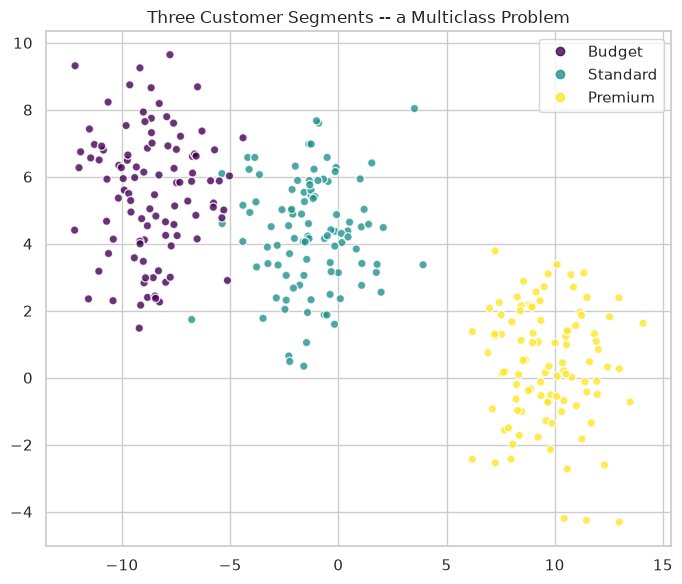

In [24]:
# Three customer segments instead of two -- Budget, Standard, Premium.
X_multi, y_multi = make_blobs(n_samples=300, centers=3, cluster_std=1.8, random_state=7)
labels = ['Budget', 'Standard', 'Premium']

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, cmap='viridis', edgecolor='white', alpha=0.8)
ax.set_title('Three Customer Segments -- a Multiclass Problem')
handles, _ = scatter.legend_elements()
ax.legend(handles, labels)
plt.tight_layout()
plt.show()

In [25]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.25,
                                                               stratify=y_multi, random_state=7)

# One-vs-Rest: train 3 binary classifiers under the hood -- 'Budget vs rest', 'Standard vs rest',
# 'Premium vs rest' -- and let whichever is most confident win. scikit-learn does this automatically
# for LogisticRegression, but wrapping it explicitly makes the mechanism visible.
ovr_clf = OneVsRestClassifier(LogisticRegression())
ovr_clf.fit(X_train_m, y_train_m)
multi_preds = ovr_clf.predict(X_test_m)

print(classification_report(y_test_m, multi_preds, target_names=labels))

              precision    recall  f1-score   support

      Budget       1.00      0.96      0.98        25
    Standard       0.96      1.00      0.98        25
     Premium       1.00      1.00      1.00        25

    accuracy                           0.99        75
   macro avg       0.99      0.99      0.99        75
weighted avg       0.99      0.99      0.99        75



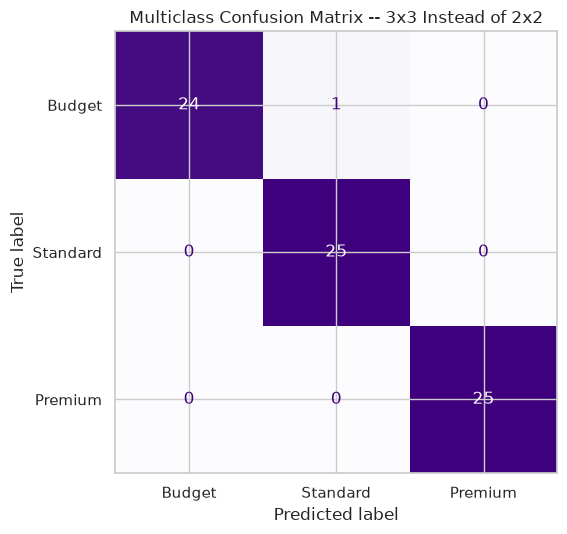

In [26]:
cm_multi = confusion_matrix(y_test_m, multi_preds)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm_multi, display_labels=labels).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Multiclass Confusion Matrix -- 3x3 Instead of 2x2')
plt.tight_layout()
plt.show()

**The confusion matrix simply grows to one row/column per class** -- the diagonal is still "got it
right," and every off-diagonal cell tells you specifically which two classes got confused with
each other, which is often more useful for debugging than a single multiclass accuracy number.
`classification_report` computes precision/recall/F1 **per class**, then averages them -- exactly
the extension the slides described.

---
## Part 13 -- Comparing Classifiers Honestly, With Cross-Validation

Nothing new mechanically -- Lecture 04's rules, applied with classification-appropriate metrics
and `StratifiedKFold` instead of plain `KFold`.

In [27]:
candidates = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics_to_check = ['accuracy', 'f1', 'roc_auc']

comparison = []
for name, model in candidates.items():
    row = {'model': name}
    for metric in metrics_to_check:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring=metric)
        row[metric] = scores.mean()
    comparison.append(row)

comparison_df = pd.DataFrame(comparison).sort_values('roc_auc', ascending=False)
print(comparison_df.round(3))

                 model  accuracy     f1  roc_auc
1  Logistic Regression     0.758  0.346    0.732
0            KNN (k=5)     0.737  0.387    0.685
2        Decision Tree     0.738  0.336    0.672


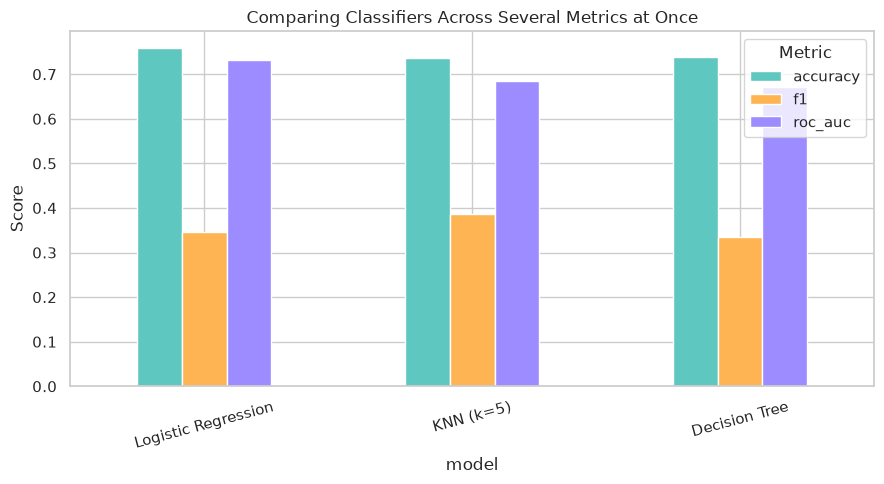

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_df.set_index('model')[metrics_to_check].plot(kind='bar', ax=ax,
                                                            color=['#5ec8c0', '#ffb454', '#9d8cff'])
ax.set_ylabel('Score')
ax.set_title('Comparing Classifiers Across Several Metrics at Once')
ax.legend(title='Metric')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Look across all three metrics together, not just one.** A model that wins on accuracy but loses
on F1 or ROC-AUC might be quietly worse at the thing that actually matters for an imbalanced,
high-stakes problem like churn -- exactly the habit the slides recommend building before Lectures
07-09 introduce three specific, more powerful classifiers to add to this comparison.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **KNN** | Classify by neighbor vote | `KNeighborsClassifier(n_neighbors=k)` -- no real "training," just stored data |
| **Decision boundaries** | Visualize over/underfitting | Small k = wiggly/overfit, large k = smooth/underfit |
| **Probabilities** | The real model output | `.predict_proba()` gives probabilities; `.predict()` just applies a cutoff |
| **Confusion matrix** | The foundation of every metric | `confusion_matrix(y_true, y_pred)` -- TP, FP, FN, TN |
| **Accuracy** | Misleading on imbalance | `accuracy_score(...)` -- always check against a "predict majority" baseline |
| **Precision / Recall** | Two kinds of "wrong" | `precision_score`, `recall_score` -- tie each to a real-world cost |
| **F1** | One balanced number | `f1_score(...)` -- punishes lopsided precision/recall harder than a plain average |
| **Threshold choice** | A business decision | Sweep thresholds, minimize a real cost function, not just eyeball 0.5 |
| **ROC / AUC** | Performance across all thresholds | `roc_curve`, `roc_auc_score` -- for comparing models overall |
| **Imbalance** | Reweight or resample training data | `class_weight='balanced'`, or `sklearn.utils.resample` on the training set only |
| **Multiclass** | Combine binary classifiers | `OneVsRestClassifier(...)`, an N×N confusion matrix, per-class metrics |
| **Model comparison** | Honest, multi-metric | `cross_val_score` with `StratifiedKFold`, checked across several metrics at once |

---

**Next lecture:** Decision Trees bring a completely different strategy -- a sequence of yes/no
questions about the features themselves, instead of KNN's "who are my neighbors?" Every evaluation
tool from today (confusion matrix, precision, recall, F1, ROC-AUC) applies immediately, unchanged.